In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re

plt.rcParams['svg.fonttype'] = 'none'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind_from_stats

dfC   = pd.read_csv('../Data/constructs_df.csv', index_col=0)
dfACT = pd.read_csv('../Data/DMSactivities.csv')
dfRE  = pd.read_csv('../Data/RePred_Activity_merged.csv')

df_re = dfACT.merge(dfRE[['mutation', 'mut_vs_wt_Re_delta_50']], on='mutation', how='left')
df_re = df_re[df_re['var_pos'] >= 100]

In [2]:
dfC[['window', 'mutation']] = dfC['construct'].str.split('_', n=1, expand=True)

wt   = dfC[dfC['mutation'] == 'WT'].set_index('window')[['Ef_cell', 'Ef_cell_std', 'n_wells']]
muts = dfC[dfC['mutation'] != 'WT'].copy()

muts = muts.join(
    wt.rename(columns={'Ef_cell': 'wt_Ef', 'Ef_cell_std': 'wt_std', 'n_wells': 'wt_n'}),
    on='window'
)

muts['delta_Ef'] = muts['Ef_cell'] - muts['wt_Ef']

def ttest_row(row):
    _, p = ttest_ind_from_stats(
        mean1=row['Ef_cell'], std1=row['Ef_cell_std'], nobs1=row['n_wells'],
        mean2=row['wt_Ef'],   std2=row['wt_std'],       nobs2=row['wt_n'],
        equal_var=False
    )
    return p

muts['pval'] = muts.apply(ttest_row, axis=1)

mut_agg = muts.groupby('mutation').agg(
    mean_delta_Ef = ('delta_Ef', 'mean'),
    min_pval      = ('pval',     'min'),
    n_windows     = ('window',   'count')
).reset_index()

df_ef = mut_agg.merge(dfACT[['mutation', 'classification']], on='mutation', how='left')

In [3]:
def count_groups(df, sig_mask, delta_col, direction='re'):
    """
    direction='re':  positive delta = expansion, negative = compaction
    direction='ef':  positive delta = compaction (higher Ef = Re decrease), negative = expansion
    """
    sig_act    = df['classification'].isin(['high_activity', 'low_activity'])
    high_act   = df['classification'] == 'high_activity'
    low_act    = df['classification'] == 'low_activity'

    if direction == 're':
        expansion  = df[delta_col] > 0
        compaction = df[delta_col] < 0
    else:
        compaction = df[delta_col] > 0
        expansion  = df[delta_col] < 0

    return {
        'exp_high':  (sig_mask & expansion  & high_act).sum(),
        'comp_low':  (sig_mask & compaction & low_act).sum(),
        'exp_low':   (sig_mask & expansion  & low_act).sum(),
        'comp_high': (sig_mask & compaction & high_act).sum(),
        're_no_act': (sig_mask & ~sig_act).sum(),
        'act_no_re': (sig_act  & ~sig_mask).sum(),
    }

sig_re = df_re['mut_vs_wt_Re_delta_50'].abs() > 0.5
counts_re = count_groups(df_re, sig_re, 'mut_vs_wt_Re_delta_50', direction='re')

sig_ef = df_ef['min_pval'] < 0.05
counts_ef = count_groups(df_ef, sig_ef, 'mean_delta_Ef', direction='ef')

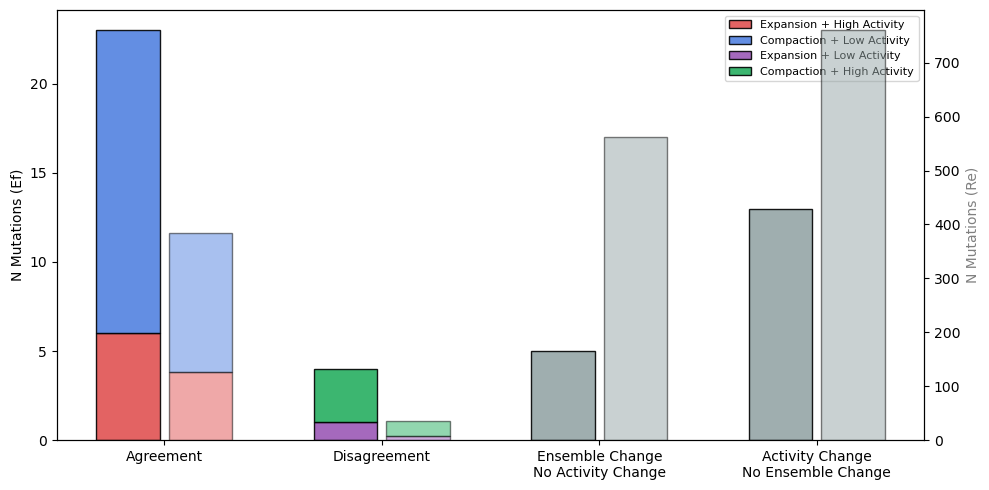

In [15]:
COLORS = {
    'exp_high':  '#e05252',
    'comp_low':  '#5282e0',
    'exp_low':   '#9b59b6',
    'comp_high': '#27ae60',
    'grey':      '#95a5a6',
}
w    = 0.35
gap  = 0.05
grp  = np.arange(4) * 1.2      # group center x positions
ef_x = grp - (w + gap) / 2     # Ef bars sit left of center
re_x = grp + (w + gap) / 2     # Re bars sit right of center

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

def draw_stacked(ax, x, counts, alpha, edge=None):
    kw = dict(width=w, alpha=alpha, edgecolor=edge)
    ax.bar(x[0], counts['exp_high'],  color=COLORS['exp_high'],  **kw, label='Expansion + High Activity')
    ax.bar(x[0], counts['comp_low'],  color=COLORS['comp_low'],  **kw, label='Compaction + Low Activity',  bottom=counts['exp_high'])
    ax.bar(x[1], counts['exp_low'],   color=COLORS['exp_low'],   **kw, label='Expansion + Low Activity')
    ax.bar(x[1], counts['comp_high'], color=COLORS['comp_high'], **kw, label='Compaction + High Activity', bottom=counts['exp_low'])
    ax.bar(x[2], counts['re_no_act'], color=COLORS['grey'],      **kw)
    ax.bar(x[3], counts['act_no_re'], color=COLORS['grey'],      **kw)

draw_stacked(ax1, ef_x, counts_ef, alpha=0.9, edge='black')
draw_stacked(ax2, re_x, counts_re, alpha=0.5, edge='black')

# x-axis ticks centered in each group
ax1.set_xticks(grp)
ax1.set_xticklabels(['Agreement', 'Disagreement', 'Ensemble Change\nNo Activity Change', 'Activity Change\nNo Ensemble Change'])
ax1.set_ylabel('N Mutations (Ef)', color='black')
ax2.set_ylabel('N Mutations (Re)', color='grey')

# Legend from ax1 only (same colors used on both)
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles, labels, fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()